Accuracy: 0.60

Classification Report:
              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5


Confusion Matrix:
[[1 1]
 [1 2]]

Cross-validation scores: [0.66666667 1.         1.         0.66666667 1.        ]
Mean CV accuracy: 0.87

Feature Importance:
            Feature  Importance
6     Humidity_High    0.400000
8       Wind_Strong    0.333333
2     Outlook_Sunny    0.266667
0  Outlook_Overcast    0.000000
1      Outlook_Rain    0.000000
3  Temperature_Cool    0.000000
4   Temperature_Hot    0.000000
5  Temperature_Mild    0.000000
7   Humidity_Normal    0.000000
9         Wind_Weak    0.000000


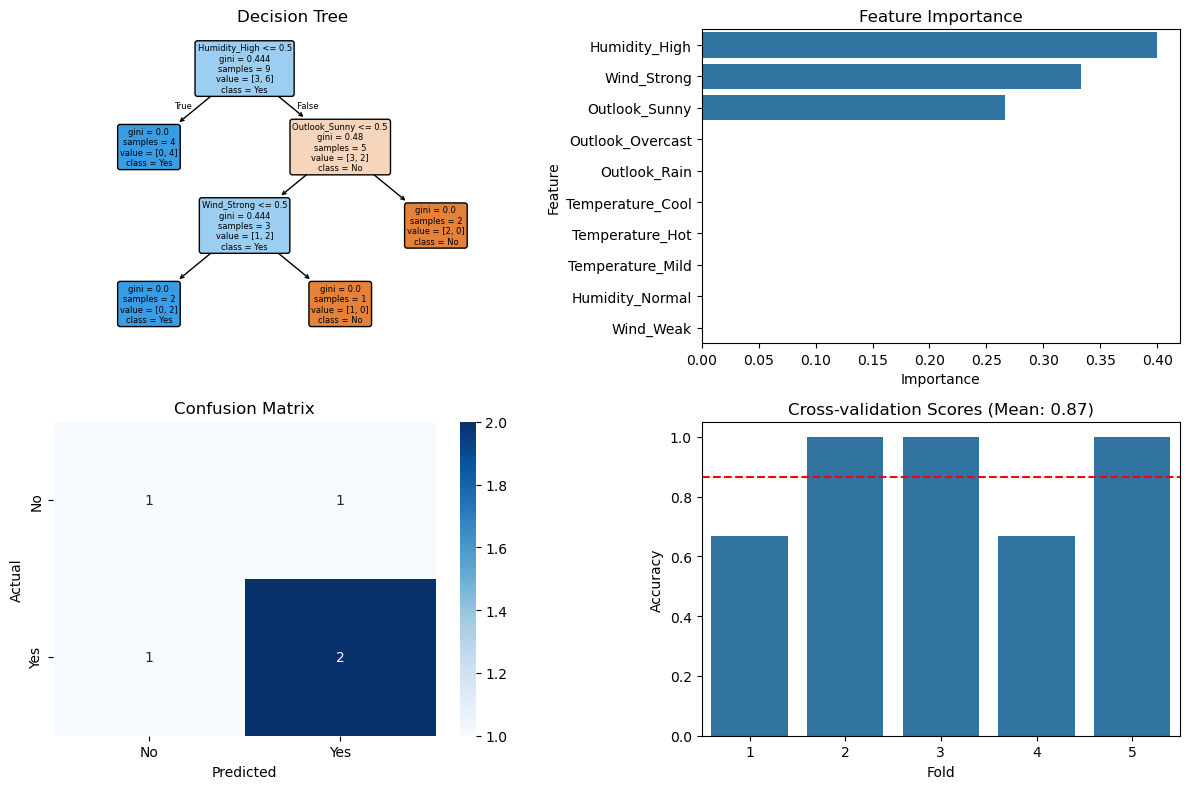

c:\Users\KIIT\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


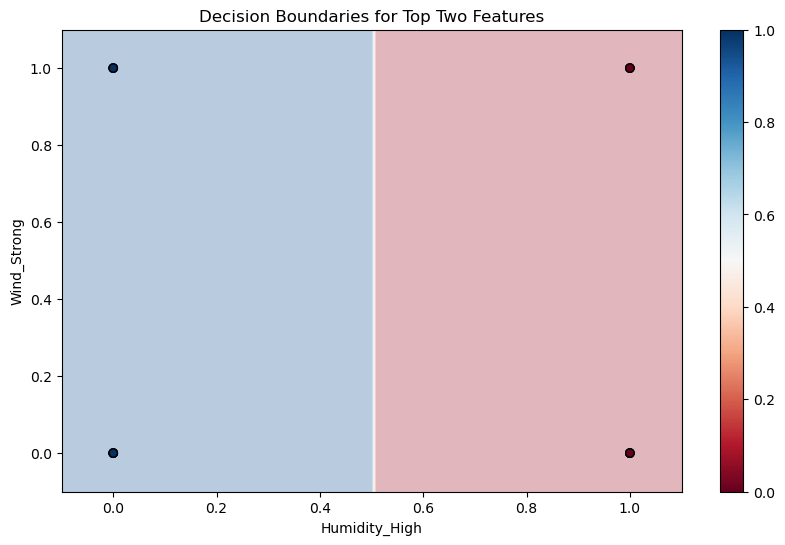

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("dataset.csv")

# Preprocessing
# Convert categorical variables to numerical
df_encoded = pd.get_dummies(df.drop(['Day', 'Play Golf'], axis=1))
y = df['Play Golf'].map({'Yes': 1, 'No': 0})

# Split the data (small dataset, so we'll use cross-validation later)
X_train, X_test, y_train, y_test = train_test_split(df_encoded, y, test_size=0.3, random_state=42)

# Train the decision tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Cross-validation to get a better estimate of model performance
cv_scores = cross_val_score(clf, df_encoded, y, cv=5)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.2f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': df_encoded.columns,
    'Importance': clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Visualizations
plt.figure(figsize=(12, 8))

# 1. Decision Tree Visualization
plt.subplot(2, 2, 1)
tree.plot_tree(clf, feature_names=df_encoded.columns, class_names=['No', 'Yes'], 
               filled=True, rounded=True, fontsize=6)
plt.title("Decision Tree")

# 2. Feature Importance
plt.subplot(2, 2, 2)
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance")
plt.tight_layout()

# 3. Confusion Matrix Heatmap
plt.subplot(2, 2, 3)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# 4. Cross-validation scores
plt.subplot(2, 2, 4)
sns.barplot(x=range(1, len(cv_scores)+1), y=cv_scores)
plt.axhline(cv_scores.mean(), color='red', linestyle='--')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title(f'Cross-validation Scores (Mean: {cv_scores.mean():.2f})')

plt.tight_layout()
plt.show()

# Additional visualization: Decision boundaries (for two most important features)
if len(feature_importance) >= 2:
    plt.figure(figsize=(10, 6))
    
    # Get the two most important features
    top_features = feature_importance['Feature'].iloc[:2].tolist()
    
    # Create a meshgrid to plot decision boundaries
    x_min, x_max = df_encoded[top_features[0]].min() - 0.1, df_encoded[top_features[0]].max() + 0.1
    y_min, y_max = df_encoded[top_features[1]].min() - 0.1, df_encoded[top_features[1]].max() + 0.1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    # Train a new classifier with only these two features
    clf_2d = DecisionTreeClassifier(random_state=42)
    clf_2d.fit(df_encoded[top_features], y)
    
    # Predict on the meshgrid
    Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    
    # Plot the data points
    scatter = plt.scatter(df_encoded[top_features[0]], df_encoded[top_features[1]], 
                          c=y, cmap='RdBu', edgecolor='k')
    
    plt.xlabel(top_features[0])
    plt.ylabel(top_features[1])
    plt.title('Decision Boundaries for Top Two Features')
    plt.colorbar(scatter)
    plt.show()